Importaciones y configuración general


In [1]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

C:\Users\Rafael\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
semilla = 42
random.seed(semilla)
np.random.seed(semilla)
torch.manual_seed(semilla)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(semilla)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo en uso:", dispositivo)

Dispositivo en uso: cpu


Clases del conjunto CIFAR-10


In [3]:
etiquetas_cifar10 = [
    "avion",
    "automovil",
    "pajaro",
    "gato",
    "venado",
    "perro",
    "rana",
    "caballo",
    "barco",
    "camion"
]

print(etiquetas_cifar10)

['avion', 'automovil', 'pajaro', 'gato', 'venado', 'perro', 'rana', 'caballo', 'barco', 'camion']


Transformaciones, carga del dataset y dataloaders

CIFAR-10 ya viene particionado en train y test. Para esta actividad se usa directamente esa partición. Las imágenes se convierten a tensores con ToTensor() y además se normalizan. Para la función extra de clasificación de imágenes arbitrarias se aplicará un preprocesamiento consistente con esta misma entrada esperada por la red.

In [4]:
media_cifar10 = (0.4914, 0.4822, 0.4465)
desviacion_cifar10 = (0.2470, 0.2435, 0.2616)

transformacion_entrenamiento = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(media_cifar10, desviacion_cifar10)
])

transformacion_prueba = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(media_cifar10, desviacion_cifar10)
])

conjunto_entrenamiento = datasets.CIFAR10(
    root="./datos",
    train=True,
    download=True,
    transform=transformacion_entrenamiento
)

conjunto_prueba = datasets.CIFAR10(
    root="./datos",
    train=False,
    download=True,
    transform=transformacion_prueba
)

tamano_lote = 128

cargador_entrenamiento = DataLoader(
    conjunto_entrenamiento,
    batch_size=tamano_lote,
    shuffle=True,
    num_workers=0
)

cargador_prueba = DataLoader(
    conjunto_prueba,
    batch_size=tamano_lote,
    shuffle=False,
    num_workers=0
)

print("Ejemplos de entrenamiento:", len(conjunto_entrenamiento))
print("Ejemplos de prueba:", len(conjunto_prueba))

C:\Users\Rafael\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Ejemplos de entrenamiento: 50000
Ejemplos de prueba: 10000


Visualización rápida de ejemplos


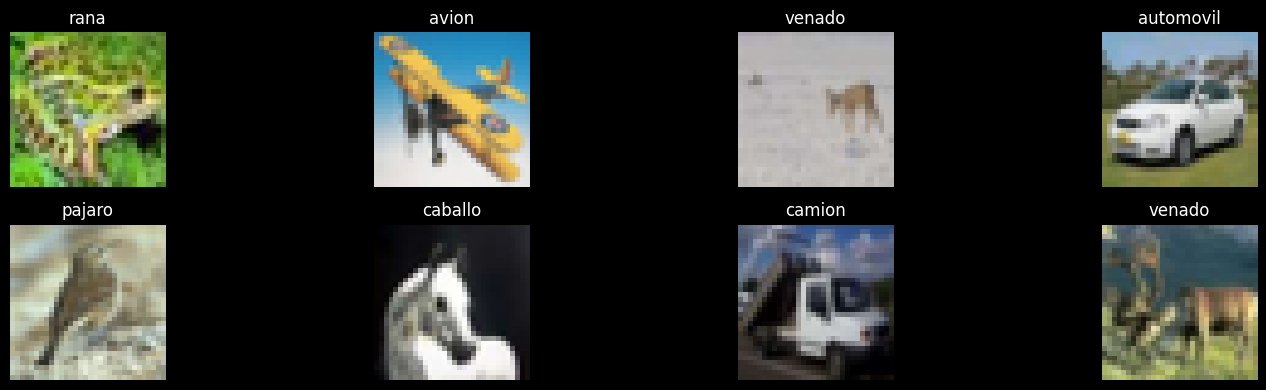

In [5]:
def desnormalizar(lote):
    media = torch.tensor(media_cifar10).view(1, 3, 1, 1)
    desviacion = torch.tensor(desviacion_cifar10).view(1, 3, 1, 1)
    return lote * desviacion + media

imagenes_ejemplo, etiquetas_ejemplo = next(iter(cargador_entrenamiento))
imagenes_mostrar = desnormalizar(imagenes_ejemplo[:8]).clamp(0, 1)

plt.figure(figsize=(16, 4))
for indice in range(8):
    plt.subplot(2, 4, indice + 1)
    imagen = imagenes_mostrar[indice].permute(1, 2, 0).numpy()
    plt.imshow(imagen)
    plt.title(etiquetas_cifar10[etiquetas_ejemplo[indice].item()])
    plt.axis("off")
plt.tight_layout()
plt.show()

Definición de las arquitecturas convolucionales

Se entrenarán 3 redes neuronales distintas. Lo único que cambia entre ellas es la arquitectura. Los hiperparámetros de entrenamiento se mantienen iguales para las tres.

In [6]:
class CNNBasica(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.red(x)


class CNNProfunda(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.red(x)


class CNNConBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.red(x)

 Funciones de entrenamiento, evaluación y gráficas


In [7]:
arquitecturas = {
    "CNN Basica": CNNBasica,
    "CNN Profunda": CNNProfunda,
    "CNN con BatchNorm": CNNConBatchNorm
}

def contar_parametros_entrenables(modelo):
    return sum(parametro.numel() for parametro in modelo.parameters() if parametro.requires_grad)

for nombre, constructor in arquitecturas.items():
    modelo = constructor()
    print(f"{nombre}: {contar_parametros_entrenables(modelo):,} parametros entrenables")

CNN Basica: 545,098 parametros entrenables
CNN Profunda: 1,116,970 parametros entrenables
CNN con BatchNorm: 1,423,114 parametros entrenables


In [8]:
def evaluar_modelo(modelo, cargador_datos, funcion_perdida):
    modelo.eval()
    perdida_acumulada = 0.0
    aciertos = 0
    total = 0

    with torch.no_grad():
        for imagenes, etiquetas in cargador_datos:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            salidas = modelo(imagenes)
            perdida = funcion_perdida(salidas, etiquetas)

            perdida_acumulada += perdida.item() * imagenes.size(0)
            predicciones = salidas.argmax(dim=1)
            aciertos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)

    perdida_promedio = perdida_acumulada / total
    accuracy = aciertos / total
    return perdida_promedio, accuracy

In [9]:
def entrenar_modelo(modelo, nombre_modelo, cargador_entrenamiento, cargador_prueba, funcion_perdida, optimizador, epocas):
    historial = {
        "perdida_entrenamiento": [],
        "perdida_prueba": [],
        "accuracy_entrenamiento": [],
        "accuracy_prueba": []
    }

    mejor_estado = copy.deepcopy(modelo.state_dict())
    mejor_accuracy_prueba = 0.0

    for epoca in range(epocas):
        modelo.train()
        perdida_acumulada = 0.0
        aciertos = 0
        total = 0

        barra = tqdm(cargador_entrenamiento, desc=f"{nombre_modelo} | Epoca {epoca + 1}/{epocas}", leave=False)

        for imagenes, etiquetas in barra:
            imagenes = imagenes.to(dispositivo)
            etiquetas = etiquetas.to(dispositivo)

            optimizador.zero_grad()
            salidas = modelo(imagenes)
            perdida = funcion_perdida(salidas, etiquetas)
            perdida.backward()
            optimizador.step()

            perdida_acumulada += perdida.item() * imagenes.size(0)
            predicciones = salidas.argmax(dim=1)
            aciertos += (predicciones == etiquetas).sum().item()
            total += etiquetas.size(0)

            barra.set_postfix({
                "loss_lote": f"{perdida.item():.4f}",
                "acc_lote": f"{(predicciones == etiquetas).float().mean().item():.4f}"
            })

        perdida_entrenamiento = perdida_acumulada / total
        accuracy_entrenamiento = aciertos / total
        perdida_prueba, accuracy_prueba = evaluar_modelo(modelo, cargador_prueba, funcion_perdida)

        historial["perdida_entrenamiento"].append(perdida_entrenamiento)
        historial["perdida_prueba"].append(perdida_prueba)
        historial["accuracy_entrenamiento"].append(accuracy_entrenamiento)
        historial["accuracy_prueba"].append(accuracy_prueba)

        if accuracy_prueba > mejor_accuracy_prueba:
            mejor_accuracy_prueba = accuracy_prueba
            mejor_estado = copy.deepcopy(modelo.state_dict())

        print(
            f"{nombre_modelo} | Epoca {epoca + 1:02d}/{epocas:02d} | "
            f"Train Loss: {perdida_entrenamiento:.4f} | Train Acc: {accuracy_entrenamiento:.4f} | "
            f"Test Loss: {perdida_prueba:.4f} | Test Acc: {accuracy_prueba:.4f}"
        )

    modelo.load_state_dict(mejor_estado)
    return historial

In [10]:
def graficar_curvas(historial, nombre_modelo):
    epocas = range(1, len(historial["perdida_entrenamiento"]) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(epocas, historial["perdida_entrenamiento"], marker="o", label="Train")
    plt.plot(epocas, historial["perdida_prueba"], marker="o", label="Test")
    plt.title(f"Perdida por epoca - {nombre_modelo}")
    plt.xlabel("Epoca")
    plt.ylabel("Perdida")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epocas, historial["accuracy_entrenamiento"], marker="o", label="Train")
    plt.plot(epocas, historial["accuracy_prueba"], marker="o", label="Test")
    plt.title(f"Accuracy por epoca - {nombre_modelo}")
    plt.xlabel("Epoca")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Hiperparámetros compartidos

El optimizador, la función de pérdida, el número de épocas y el resto de los hiperparámetros se mantienen iguales para los 3 modelos. Solo cambia la arquitectura.

In [11]:
epocas = 10
tasa_aprendizaje = 0.001
funcion_perdida = nn.CrossEntropyLoss()

print("Epocas:", epocas)
print("Tasa de aprendizaje:", tasa_aprendizaje)
print("Tamano de lote:", tamano_lote)

Epocas: 10
Tasa de aprendizaje: 0.001
Tamano de lote: 128


Entrenamiento de las 3 redes neuronales

In [12]:
modelos_entrenados = {}
historiales = {}
resultados_finales = {}

for nombre_modelo, constructor in arquitecturas.items():
    print(f"\nEntrenando {nombre_modelo}")
    modelo = constructor().to(dispositivo)
    optimizador = torch.optim.Adam(modelo.parameters(), lr=tasa_aprendizaje)

    historial = entrenar_modelo(
        modelo=modelo,
        nombre_modelo=nombre_modelo,
        cargador_entrenamiento=cargador_entrenamiento,
        cargador_prueba=cargador_prueba,
        funcion_perdida=funcion_perdida,
        optimizador=optimizador,
        epocas=epocas
    )

    perdida_final_prueba, accuracy_final_prueba = evaluar_modelo(modelo, cargador_prueba, funcion_perdida)

    modelos_entrenados[nombre_modelo] = modelo
    historiales[nombre_modelo] = historial
    resultados_finales[nombre_modelo] = {
        "perdida_prueba": perdida_final_prueba,
        "accuracy_prueba": accuracy_final_prueba,
        "parametros": contar_parametros_entrenables(modelo)
    }

    print(
        f"Resultado final de {nombre_modelo} -> "
        f"Test Loss: {perdida_final_prueba:.4f} | Test Acc: {accuracy_final_prueba:.4f}"
    )


Entrenando CNN Basica


CNN Basica | Epoca 01/10 | Train Loss: 1.3728 | Train Acc: 0.5099 | Test Loss: 1.0902 | Test Acc: 0.6205


CNN Basica | Epoca 02/10 | Train Loss: 0.9941 | Train Acc: 0.6492 | Test Loss: 0.9370 | Test Acc: 0.6668


CNN Basica | Epoca 03/10 | Train Loss: 0.8413 | Train Acc: 0.7069 | Test Loss: 0.9228 | Test Acc: 0.6760


CNN Basica | Epoca 04/10 | Train Loss: 0.7404 | Train Acc: 0.7411 | Test Loss: 0.8631 | Test Acc: 0.6986


...

CNN con BatchNorm | Epoca 06/10 | Train Loss: 0.5550 | Train Acc: 0.8046 | Test Loss: 0.7260 | Test Acc: 0.7504


CNN con BatchNorm | Epoca 07/10 | Train Loss: 0.4884 | Train Acc: 0.8276 | Test Loss: 0.7620 | Test Acc: 0.7595


CNN con BatchNorm | Epoca 08/10 | Train Loss: 0.4394 | Train Acc: 0.8465 | Test Loss: 0.6357 | Test Acc: 0.7906


CNN con BatchNorm | Epoca 09/10 | Train Loss: 0.3837 | Train Acc: 0.8633 | Test Loss: 0.6417 | Test Acc: 0.8007


CNN con BatchNorm | Epoca 10/10 | Train Loss: 0.3311 | Train Acc: 0.8820 | Test Loss: 0.6562 | Test Acc: 0.7971
Resultado final de CNN con BatchNorm -> Test Loss: 0.6417 | Test Acc: 0.8007


 Curvas de aprendizaje para los 3 modelos


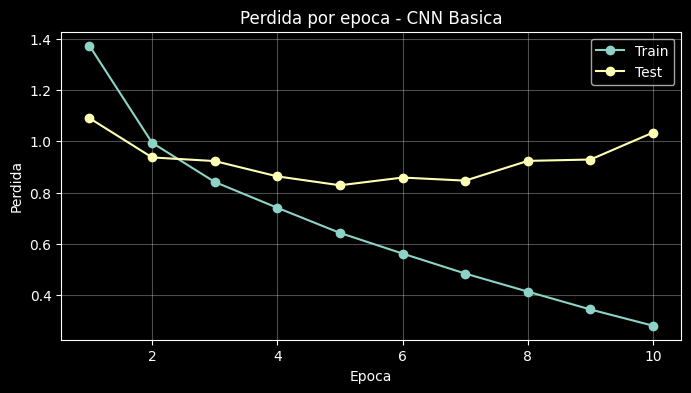

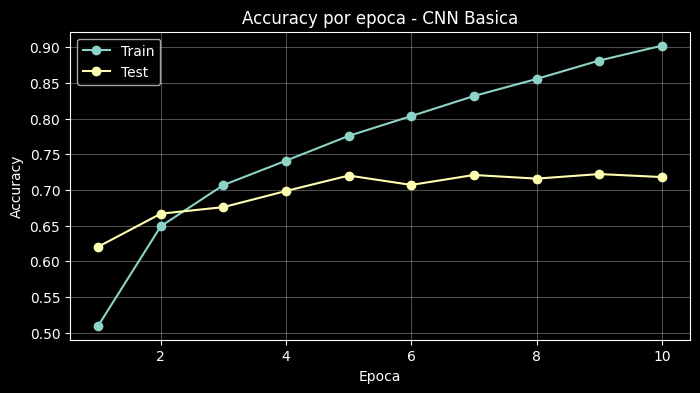

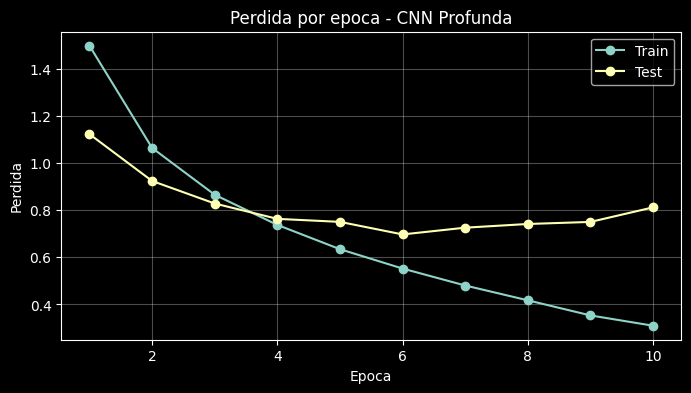

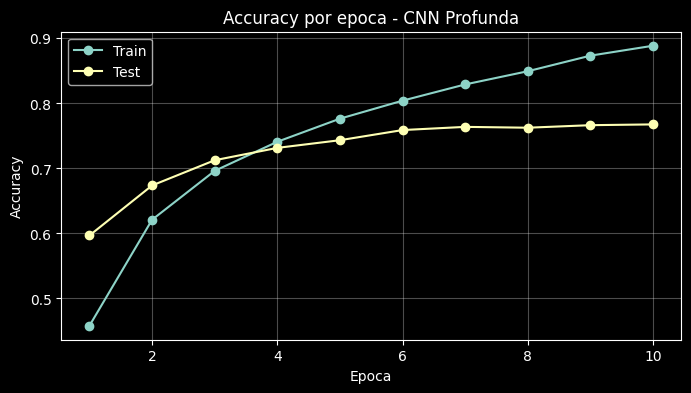

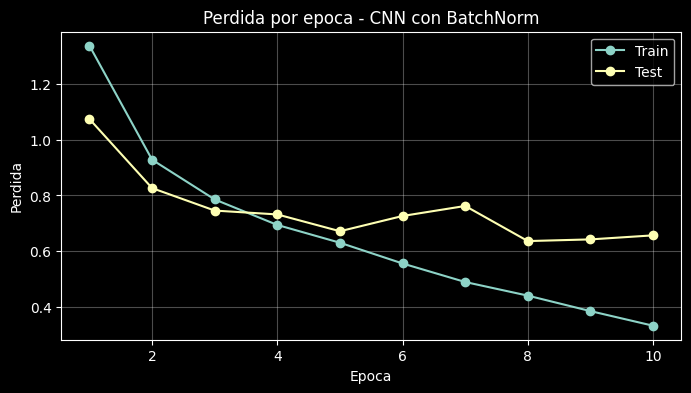

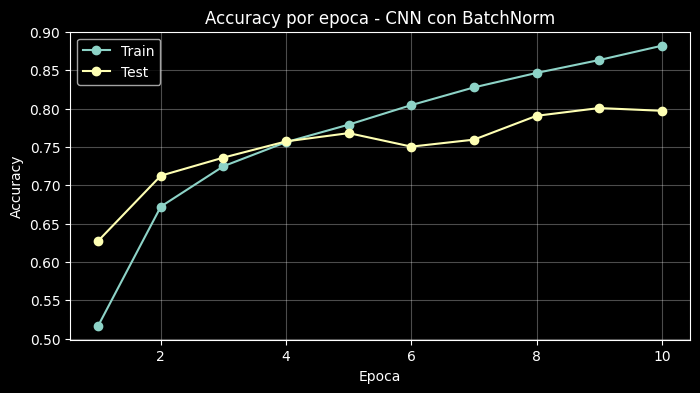

In [13]:
for nombre_modelo, historial in historiales.items():
    graficar_curvas(historial, nombre_modelo)

In [14]:
for nombre_modelo, resultado in resultados_finales.items():
    print(
        f"{nombre_modelo:20} | "
        f"Parametros: {resultado['parametros']:>10,} | "
        f"Test Loss: {resultado['perdida_prueba']:.4f} | "
        f"Test Acc: {resultado['accuracy_prueba']:.4f}"
    )

CNN Basica           | Parametros:    545,098 | Test Loss: 0.9288 | Test Acc: 0.7223
CNN Profunda         | Parametros:  1,116,970 | Test Loss: 0.8119 | Test Acc: 0.7677
CNN con BatchNorm    | Parametros:  1,423,114 | Test Loss: 0.6417 | Test Acc: 0.8007


In [15]:
nombre_mejor_modelo = max(resultados_finales, key=lambda nombre: resultados_finales[nombre]["accuracy_prueba"])
modelo_mejor = modelos_entrenados[nombre_mejor_modelo]

perdida_mejor_modelo, accuracy_mejor_modelo = evaluar_modelo(modelo_mejor, cargador_prueba, funcion_perdida)

print("Mejor modelo:", nombre_mejor_modelo)
print(f"Perdida en test del mejor modelo: {perdida_mejor_modelo:.4f}")
print(f"Accuracy en test del mejor modelo: {accuracy_mejor_modelo:.4f}")

Mejor modelo: CNN con BatchNorm
Perdida en test del mejor modelo: 0.6417
Accuracy en test del mejor modelo: 0.8007


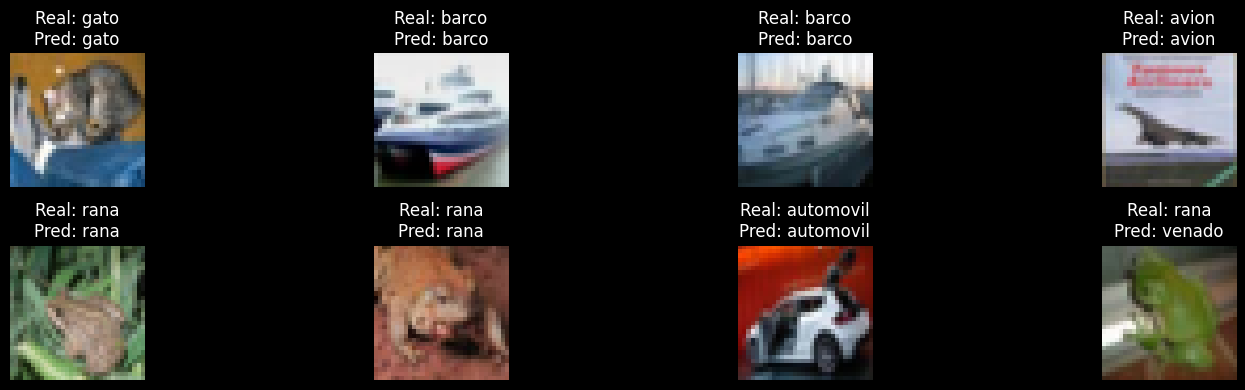

In [16]:
modelo_mejor.eval()

imagenes_prueba, etiquetas_prueba = next(iter(cargador_prueba))
imagenes_prueba = imagenes_prueba[:8].to(dispositivo)
etiquetas_prueba = etiquetas_prueba[:8]

with torch.no_grad():
    salidas = modelo_mejor(imagenes_prueba)
    predicciones = salidas.argmax(dim=1).cpu()

imagenes_mostrar = desnormalizar(imagenes_prueba.cpu()).clamp(0, 1)

plt.figure(figsize=(16, 4))
for indice in range(8):
    plt.subplot(2, 4, indice + 1)
    imagen = imagenes_mostrar[indice].permute(1, 2, 0).numpy()
    plt.imshow(imagen)
    real = etiquetas_cifar10[etiquetas_prueba[indice].item()]
    predicha = etiquetas_cifar10[predicciones[indice].item()]
    plt.title(f"Real: {real}\nPred: {predicha}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
transformacion_inferencia = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(media_cifar10, desviacion_cifar10)
])

def clasificar_imagen(ruta_imagen, modelo=None):
    if modelo is None:
        modelo = modelo_mejor

    imagen = Image.open(ruta_imagen).convert("RGB")
    tensor = transformacion_inferencia(imagen).unsqueeze(0).to(dispositivo)

    modelo.eval()
    with torch.no_grad():
        salida = modelo(tensor)
        indice_predicho = salida.argmax(dim=1).item()

    return etiquetas_cifar10[indice_predicho]

In [18]:
def mostrar_clasificacion_imagen(ruta_imagen, modelo=None):
    etiqueta = clasificar_imagen(ruta_imagen, modelo=modelo)
    imagen = Image.open(ruta_imagen).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(imagen)
    plt.title(f"Prediccion: {etiqueta}")
    plt.axis("off")
    plt.show()

    return etiqueta

In [19]:
carpeta_imagenes_usuario = r"C:\Users\Rafael\Documents\GitHub\computo-inteligente-Rafael-Negrete-Leyva\imagenes"
nombre_archivo_imagen = ""
extensiones_validas = (".png", ".jpg", ".jpeg", ".bmp", ".webp")

def clasificar_imagenes_en_carpeta(carpeta, modelo=None):
    rutas = [
        os.path.join(carpeta, archivo)
        for archivo in os.listdir(carpeta)
        if archivo.lower().endswith(extensiones_validas)
    ]

    if len(rutas) == 0:
        print("No se encontraron imagenes compatibles en la carpeta.")
        return {}

    resultados = {}
    for ruta in sorted(rutas):
        etiqueta = clasificar_imagen(ruta, modelo=modelo)
        resultados[ruta] = etiqueta
        print(f"{os.path.basename(ruta)} -> {etiqueta}")

    return resultados

if os.path.isdir(carpeta_imagenes_usuario):
    if nombre_archivo_imagen:
        ruta_imagen_usuario = os.path.join(carpeta_imagenes_usuario, nombre_archivo_imagen)
        if os.path.exists(ruta_imagen_usuario):
            etiqueta_predicha = mostrar_clasificacion_imagen(ruta_imagen_usuario, modelo=modelo_mejor)
            print("Etiqueta predicha:", etiqueta_predicha)
        else:
            print("El archivo indicado no existe dentro de la carpeta configurada.")
    else:
        resultados_carpeta = clasificar_imagenes_en_carpeta(carpeta_imagenes_usuario, modelo=modelo_mejor)
else:
    print("La carpeta configurada no existe. Verifica la ruta en la variable carpeta_imagenes_usuario.")


130118205115_sp_batimovil_304x171_bbc_nocredit.jpg.webp -> automovil
1578964252_117131_1578976412_noticia_normal.jpg -> pajaro
500_333.jpeg -> avion
5cb1f9400891d9da5a4926d7814bd1b89127ecba-1300x867.webp -> perro
Captura-de-pantalla-2021-02-08-a-las-13.59.48.png -> gato
containertruck1.webp -> camion
hq720.jpg -> caballo
image.webp -> barco
lana.jpg -> rana
white-tailed_deer_5924np.jpg -> venado


En conclusión, las tres CNN lograron aprender patrones útiles de CIFAR-10, pero la que obtuvo el mejor desempeño fue la CNN con BatchNorm, ya que alcanzó el mayor accuracy en test y la menor pérdida, por lo que fue correcto seleccionarla como el mejor modelo. Las curvas de aprendizaje también permitieron notar que, aunque los modelos mejoran en entrenamiento, existe cierto sobreajuste al compararlos con prueba. En lo personal, lo más importante de esta actividad no fue aprender desde cero la parte de gráficas, porque eso ya se había trabajado en la materia de Gráficas y Visualización, sino aplicar ese conocimiento ahora dentro de PyTorch para analizar el comportamiento de los modelos, comparar resultados y justificar de manera más clara cuál arquitectura funcionó mejor.